In [153]:
path = "C:/AMPL/"


In [154]:
pip install amplpy


Note: you may need to restart the kernel to use updated packages.


In [155]:
# Source - https://stackoverflow.com/q/30558087
# Posted by megashigger, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-12, License - CC BY-SA 3.0

from matplotlib import pyplot as plt

import matplotlib.pyplot as plt 


In [156]:
from amplpy import AMPL, add_to_path

# Add AMPL folder to the search path
add_to_path("C:/AMPL/")  # ✅

# Create an AMPL object
ampl = AMPL()


In [7]:
from amplpy import AMPL, add_to_path

# 1. Add the AMPL folder to the search path
add_to_path("C:/AMPL/")  # use forward slashes to avoid \ issues

# 2. Create AMPL object
ampl = AMPL()

# 3. Set solver
ampl.setOption("solver", "gurobi")
ampl.setOption("gurobi_options", "timelim=1800")

# 4. Load your model
ampl.read("C:/Users/betsie_0410/Downloads/AMPL/Partial_domination/F1.mod")  # <-- change to your actual path

# 5. Set results file
resultsfile_path = "C:/Users/betsie_0410/Downloads/AMPL/Partial_domination/BD0/BD0_1.txt"
# make sure the folder exists, Python won't create it automatically
resultsfile = open(resultsfile_path, "w")

# 6. Loop over your data files
for g in range(1, 57):
    ampl.eval("reset data;")  # <-- reset only data, not model
    data_file = f"C:/Users/betsie_0410/Downloads/AMPL/Partial_domination/BD0/Grafo{g}.dat"
    ampl.readData(data_file)
    
    # Write g to results file
    resultsfile.write(f"{g} & ")
    
    # Solve
    ampl.solve()
    
    # Get objective value
    f = ampl.getObjective("f").value()
    
    # Get problem size variables
    n = ampl.getParameter("n").value()
    m = ampl.getParameter("m").value()
    
    # Write results
    solve_time = ampl.getValue("_solve_elapsed_time")
    resultsfile.write(f"{n} & {m} & {f:.3f} & {solve_time:.4f} \\\\\n")
    
# 7. Close the file
resultsfile.close()


Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 6
77 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 6
56 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 6
82 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 5
74 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 6
113 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 5
123 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 6
130 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solution; objective 6
131 simplex iterations
1 branching node
Gurobi 13.0.0:   lim:time = 1800
Gurobi 13.0.0: optimal solu

Plots with the running times

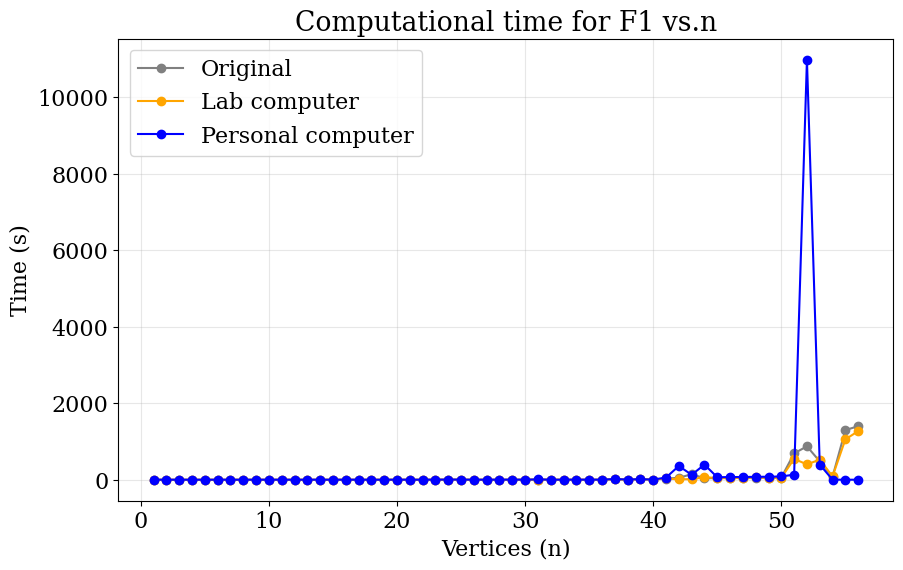

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'x_': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
        'y_': [
    0.2185, 0.0649, 0.0610, 0.0657, 0.0743, 0.0577, 0.0530, 0.0530,
    0.1219, 0.0834, 0.1802, 0.2017, 0.1384, 0.2894, 0.1208, 0.3458,
    0.2718, 0.2537, 0.2472, 0.3306, 0.3944, 0.3690, 2.0777, 2.6636,
    2.3164, 0.5189, 0.6089, 0.5541, 0.6824, 0.6318, 5.3633, 0.5379,
    0.8448, 1.1021, 0.8779, 1.1029, 22.9978, 2.1478, 24.8084, 1.1585,
    29.3494, 50.2796, 144.7011, 39.3879, 43.6427, 44.0887, 46.2590,
    50.7982, 50.3618, 57.2198, 687.8167, 872.8838, 479.0030,
    80.4483, 1297.3588, 1398.5607
],
        'color': 'gray',
        'label': 'Original'
    },

    {
        'x_': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
        'y_': [
    0.1250, 0.0160, 0.0320, 0.0160, 0.0310, 0.0320, 0.0320, 0.0310,
    0.1250, 0.0470, 0.1400, 0.1720, 0.0930, 0.2030, 0.0780, 0.2190,
    0.2650, 0.3440, 0.3290, 0.5630, 0.7500, 0.6560, 2.2810, 2.5150,
    1.0940, 0.7190, 0.5310, 0.5780, 1.0470, 0.8910, 3.5620, 2.3130,
    1.0000, 1.3130, 0.8910, 1.5630, 7.8130, 5.1410, 6.9370, 3.7500,
    32.5940, 10.4220, 15.4690, 67.1880, 43.8750, 44.5620, 51.9850,
    63.8600, 51.7500, 52.0160, 544.2660, 400.5780, 525.4220,
    84.9220, 1054.3750, 1270.6250
],
        'color': 'orange',
        'label': 'Lab computer'
    },

    {
        'x_': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
        'y_': [
    0.4850, 0.2180, 0.1870, 0.1400, 0.1570, 0.1720, 0.1720, 0.1720,
    0.3590, 0.2340, 0.4530, 0.5000, 0.2970, 0.6250, 0.2660, 0.8910,
    0.5160, 0.4220, 0.4220, 1.1400, 0.6560, 0.6560, 2.2340, 4.0000,
    3.3590, 1.0470, 1.0780, 0.9850, 3.4690, 1.3130, 8.6410, 0.8900,
    1.3430, 1.6720, 1.5470, 1.8750, 17.6090, 4.8440, 14.0470, 3.2650,
    56.9530, 358.9380, 129.0790, 394.6100, 64.4850, 70.0460, 70.6880,
    76.4210, 77.3280, 85.9850, 132.0150, 10977.5780, 396.3910,
    0.5470, 0.4380, 0.3750
],
        'color': 'blue',
        'label': 'Personal computer'
    },
]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'], marker='o')
#    ax.scatter(data['x_'], data['y_'], color=data['color'], s=50, label=data['label'], marker='o')


plt.title('Computational time for F1 vs.n')
plt.ylabel('Time (s)')
plt.xlabel('Vertices (n)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()

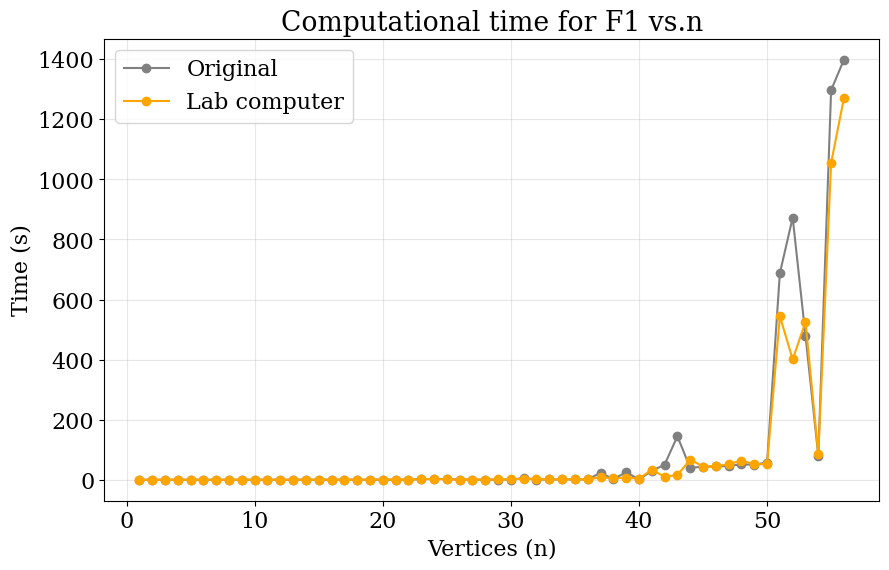

In [11]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import rc

rc('font', **{'family': 'serif',
    'serif': ['Computer Modern'], 'size': 16})

# Define multiple sets of data for each line
datasets = [
    {
        'x_': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
        'y_': [
    0.2185, 0.0649, 0.0610, 0.0657, 0.0743, 0.0577, 0.0530, 0.0530,
    0.1219, 0.0834, 0.1802, 0.2017, 0.1384, 0.2894, 0.1208, 0.3458,
    0.2718, 0.2537, 0.2472, 0.3306, 0.3944, 0.3690, 2.0777, 2.6636,
    2.3164, 0.5189, 0.6089, 0.5541, 0.6824, 0.6318, 5.3633, 0.5379,
    0.8448, 1.1021, 0.8779, 1.1029, 22.9978, 2.1478, 24.8084, 1.1585,
    29.3494, 50.2796, 144.7011, 39.3879, 43.6427, 44.0887, 46.2590,
    50.7982, 50.3618, 57.2198, 687.8167, 872.8838, 479.0030,
    80.4483, 1297.3588, 1398.5607
],
        'color': 'gray',
        'label': 'Original'
    },

    {
        'x_': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38,
 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56],
        'y_': [
    0.1250, 0.0160, 0.0320, 0.0160, 0.0310, 0.0320, 0.0320, 0.0310,
    0.1250, 0.0470, 0.1400, 0.1720, 0.0930, 0.2030, 0.0780, 0.2190,
    0.2650, 0.3440, 0.3290, 0.5630, 0.7500, 0.6560, 2.2810, 2.5150,
    1.0940, 0.7190, 0.5310, 0.5780, 1.0470, 0.8910, 3.5620, 2.3130,
    1.0000, 1.3130, 0.8910, 1.5630, 7.8130, 5.1410, 6.9370, 3.7500,
    32.5940, 10.4220, 15.4690, 67.1880, 43.8750, 44.5620, 51.9850,
    63.8600, 51.7500, 52.0160, 544.2660, 400.5780, 525.4220,
    84.9220, 1054.3750, 1270.6250
],
        'color': 'orange',
        'label': 'Lab computer'
    },

]

# Plot all lines on the same graph
fig, ax = plt.subplots(figsize=(10, 6))

for data in datasets:
    ax.plot(data['x_'], data['y_'], color=data['color'], label=data['label'], marker='o')
#    ax.scatter(data['x_'], data['y_'], color=data['color'], s=50, label=data['label'], marker='o')


plt.title('Computational time for F1 vs.n')
plt.ylabel('Time (s)')
plt.xlabel('Vertices (n)')
plt.grid(alpha=0.3)
plt.legend()
plt.rcdefaults()
plt.show()

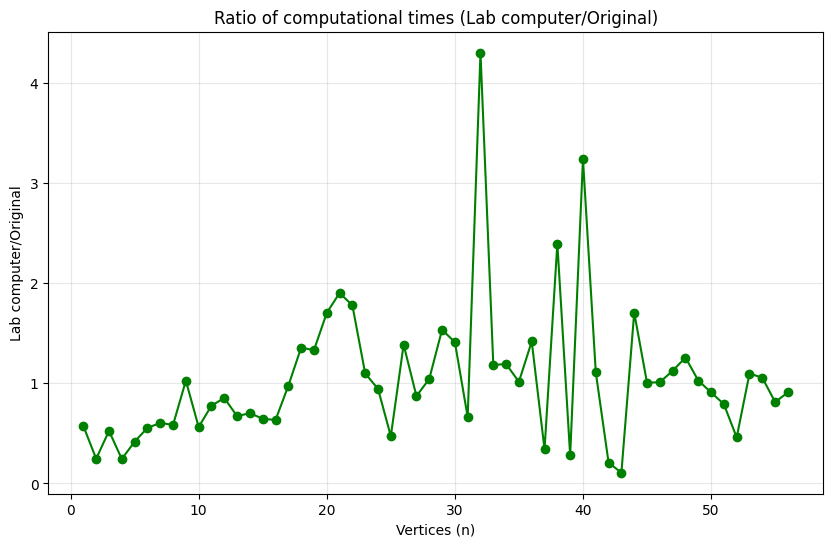

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Original and Lab computer times
y_original = np.array([
    0.2185, 0.0649, 0.0610, 0.0657, 0.0743, 0.0577, 0.0530, 0.0530,
    0.1219, 0.0834, 0.1802, 0.2017, 0.1384, 0.2894, 0.1208, 0.3458,
    0.2718, 0.2537, 0.2472, 0.3306, 0.3944, 0.3690, 2.0777, 2.6636,
    2.3164, 0.5189, 0.6089, 0.5541, 0.6824, 0.6318, 5.3633, 0.5379,
    0.8448, 1.1021, 0.8779, 1.1029, 22.9978, 2.1478, 24.8084, 1.1585,
    29.3494, 50.2796, 144.7011, 39.3879, 43.6427, 44.0887, 46.2590,
    50.7982, 50.3618, 57.2198, 687.8167, 872.8838, 479.0030,
    80.4483, 1297.3588, 1398.5607
])

y_lab = np.array([
    0.1250, 0.0160, 0.0320, 0.0160, 0.0310, 0.0320, 0.0320, 0.0310,
    0.1250, 0.0470, 0.1400, 0.1720, 0.0930, 0.2030, 0.0780, 0.2190,
    0.2650, 0.3440, 0.3290, 0.5630, 0.7500, 0.6560, 2.2810, 2.5150,
    1.0940, 0.7190, 0.5310, 0.5780, 1.0470, 0.8910, 3.5620, 2.3130,
    1.0000, 1.3130, 0.8910, 1.5630, 7.8130, 5.1410, 6.9370, 3.7500,
    32.5940, 10.4220, 15.4690, 67.1880, 43.8750, 44.5620, 51.9850,
    63.8600, 51.7500, 52.0160, 544.2660, 400.5780, 525.4220,
    84.9220, 1054.3750, 1270.6250
])

x = np.arange(1, 57)

# Compute the ratio
ratio = y_lab/y_original

# Plot the ratio
plt.figure(figsize=(10, 6))
plt.plot(x, ratio, marker='o', color='green')
plt.xlabel('Vertices (n)')
plt.ylabel('Lab computer/Original')
plt.title('Ratio of computational times (Lab computer/Original)')
plt.grid(alpha=0.3)
plt.show()


Data visualization BD0

In [157]:
import glob
import os

base_path = r"C:\Users\betsie_0410\Downloads\results-random\results-random"

files = glob.glob(os.path.join(base_path, "**", "*.txt"), recursive=True)

print("Number of files found:", len(files))
print(files[:5])

Number of files found: 33
['C:\\Users\\betsie_0410\\Downloads\\results-random\\results-random\\BD0\\BD0_0.5.txt', 'C:\\Users\\betsie_0410\\Downloads\\results-random\\results-random\\BD0\\BD0_0.6.txt', 'C:\\Users\\betsie_0410\\Downloads\\results-random\\results-random\\BD0\\BD0_0.7.txt', 'C:\\Users\\betsie_0410\\Downloads\\results-random\\results-random\\BD0\\BD0_0.8.txt', 'C:\\Users\\betsie_0410\\Downloads\\results-random\\results-random\\BD0\\BD0_0.9.txt']


In [158]:
all_data = []

for file in files:
    df = pd.read_csv(file, sep="&", header=None, engine="python")

    df = df.apply(lambda col: col.astype(str).str.replace("\\\\", "").str.strip())
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()

    if not df.empty:
        df.columns = ["exp", "m", "size_metric", "obj_value", "solve_time"]
        df["file"] = os.path.basename(file)
        all_data.append(df)

if all_data:
    final_df = pd.concat(all_data, ignore_index=True)
    print("Final shape:", final_df.shape)
else:
    print("No valid data found.")


Final shape: (6120, 6)


In [159]:
import os
import pandas as pd
import glob

base_path = r"C:\Users\betsie_0410\Downloads\results-random\results-random"

files = glob.glob(os.path.join(base_path, "**", "*.txt"), recursive=True)

all_data = []

for file in files:
    df = pd.read_csv(file, sep="&", header=None, engine="python")

    df = df.apply(lambda col: col.astype(str).str.replace("\\\\", "").str.strip())
    df = df.apply(pd.to_numeric, errors='coerce')
    df = df.dropna()

    if not df.empty:
        df.columns = ["exp", "n", "m", "obj_value", "solve_time"]

        # 👇 extract file and folder
        df["file"] = os.path.basename(file)
        df["folder"] = os.path.basename(os.path.dirname(file))

        all_data.append(df)

final_df = pd.concat(all_data, ignore_index=True)

print(final_df.head())


   exp     n      m  obj_value  solve_time         file folder
0    1  50.0  306.0        2.0      0.3837  BD0_0.5.txt    BD0
1    2  55.0  371.0        2.0      0.1312  BD0_0.5.txt    BD0
2    3  60.0  442.0        2.0      0.0602  BD0_0.5.txt    BD0
3    4  65.0  693.0        2.0      0.0495  BD0_0.5.txt    BD0
4    5  70.0  603.0        2.0      0.0491  BD0_0.5.txt    BD0


In [160]:
print(final_df["file"].unique())


['BD0_0.5.txt' 'BD0_0.6.txt' 'BD0_0.7.txt' 'BD0_0.8.txt' 'BD0_0.9.txt'
 'BD0_1.txt' 'BD1_0.5.txt' 'BD1_0.6.txt' 'BD1_0.7.txt' 'BD1_0.8.txt'
 'BD1_0.9.txt' 'BD1_0.9KC.txt' 'BD1_1.txt' 'BD1_KC_LP_0.9.txt'
 'BD1_LP_0.9.txt' 'BD3_0.5.txt' 'BD3_0.6.txt' 'BD3_0.7.txt' 'BD3_0.8.txt'
 'BD3_0.9.txt' 'BD3_1.txt' 'BD5_0.5.txt' 'BD5_0.6.txt' 'BD5_0.7.txt'
 'BD5_0.8.txt' 'BD5_0.9.txt' 'BD5_1.txt' 'BD6_0.5.txt' 'BD6_0.6.txt'
 'BD6_0.7.txt' 'BD6_0.8.txt' 'BD6_0.9.txt' 'BD6_1.txt']


In [161]:
selected_files = final_df["file"].unique()[:6]
print(selected_files)


['BD0_0.5.txt' 'BD0_0.6.txt' 'BD0_0.7.txt' 'BD0_0.8.txt' 'BD0_0.9.txt'
 'BD0_1.txt']


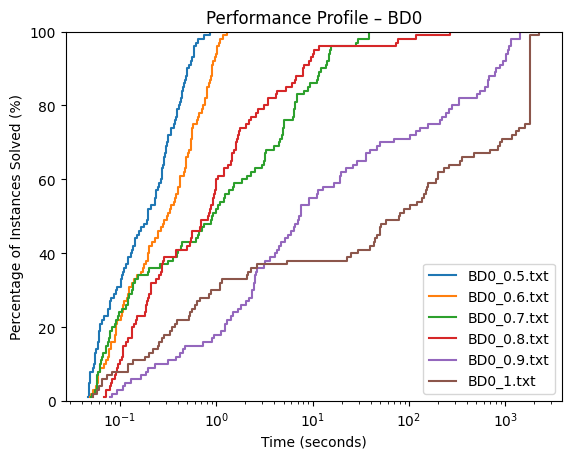

In [162]:
import numpy as np
import matplotlib.pyplot as plt

custom_labels = [
    "BD0 0.5",
    "BD0 0.6",
    "BD0 0.7",
    "BD0 0.8",
    "BD0 0.9",
    "BD0 1.0"
]

plt.figure()

for file in selected_files:
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)

    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

  # Remove .txt from label if present
    plt.step(times, percentages, where="post", label=file)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD0")
plt.show()


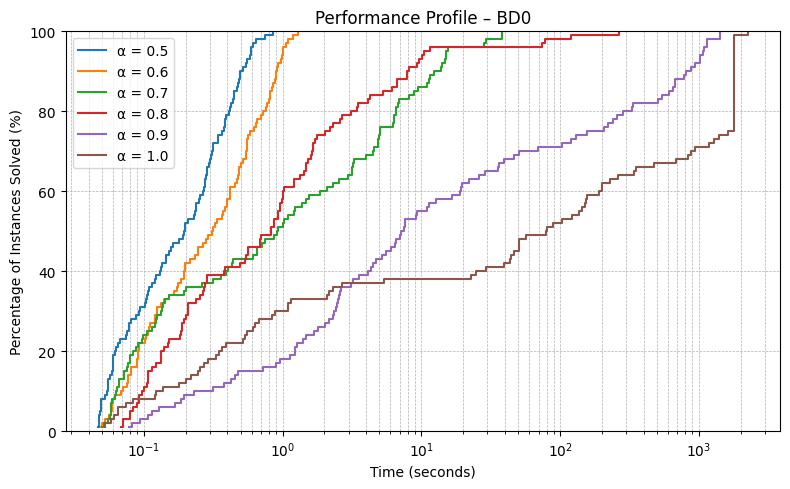

In [163]:
import numpy as np
import matplotlib.pyplot as plt

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

plt.figure(figsize=(8,5))

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt", "")
    plt.step(times, percentages, where="post", label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard for performance profiles
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD0")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


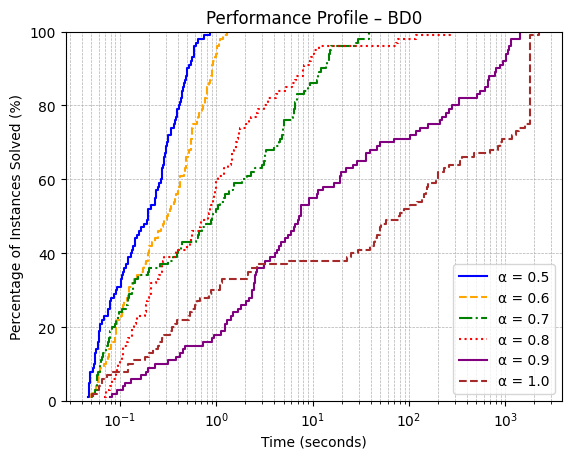

In [164]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

# Use default figure size (same as original)
plt.figure()

# Cycle colors and line styles for clarity
colors = cycle(['blue', 'orange', 'green', 'red', 'purple', 'brown'])
linestyles = cycle(['-', '--', '-.', ':', '-', '--'])

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # Optional: filter by folder
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label if available
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt","")

    plt.step(times, percentages, where='post', label=label,
             color=next(colors), linestyle=next(linestyles))

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")
plt.ylim(0, 100)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.title("Performance Profile – BD0")
plt.show()


Data visualization BD1

In [165]:
selected_files = ["BD1_0.5.txt","BD1_0.6.txt","BD1_0.7.txt","BD1_0.8.txt","BD1_0.9.txt","BD1_1.txt"]
print(selected_files)

['BD1_0.5.txt', 'BD1_0.6.txt', 'BD1_0.7.txt', 'BD1_0.8.txt', 'BD1_0.9.txt', 'BD1_1.txt']


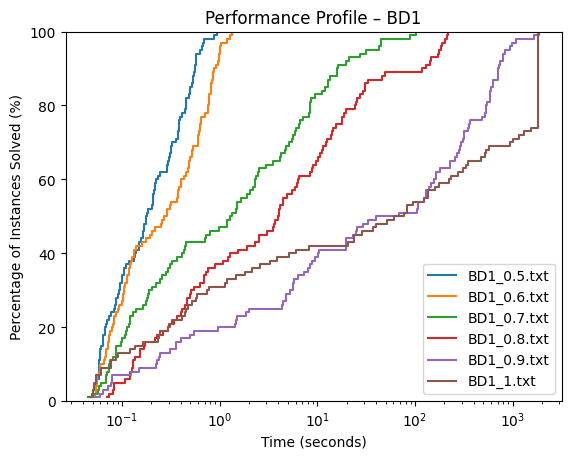

In [166]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

for file in selected_files:
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)

    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    plt.step(times, percentages, where="post", label=file)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD1")
plt.show()


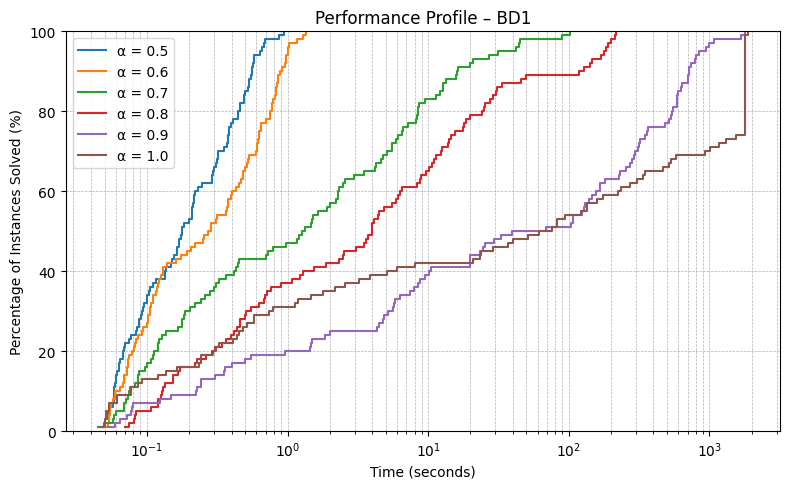

In [167]:
import numpy as np
import matplotlib.pyplot as plt

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

plt.figure(figsize=(8,5))

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt", "")
    plt.step(times, percentages, where="post", label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard for performance profiles
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD1")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


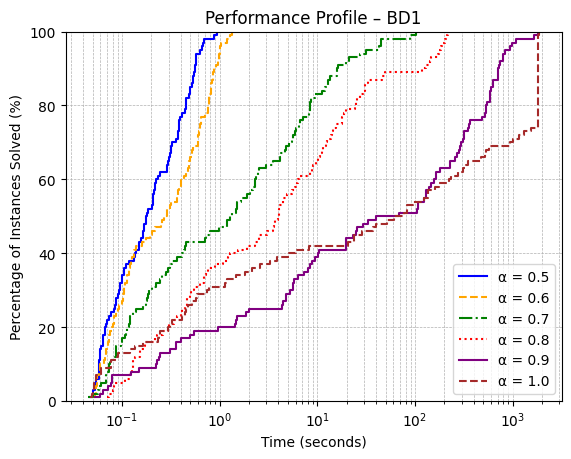

In [168]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

# Use default figure size (same as original)
plt.figure()

# Cycle colors and line styles for clarity
colors = cycle(['blue', 'orange', 'green', 'red', 'purple', 'brown'])
linestyles = cycle(['-', '--', '-.', ':', '-', '--'])

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # Optional: filter by folder
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label if available
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt","")

    plt.step(times, percentages, where='post', label=label,
             color=next(colors), linestyle=next(linestyles))

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")
plt.ylim(0, 100)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.title("Performance Profile – BD1")
plt.show()


BD1_0.9 with different formulations

In [169]:
selected_files = ["BD1_0.9.txt","BD1_0.9KC.txt","BD1_KC_LP_0.9.txt","BD1_LP_0.9.txt"]
print(selected_files)

['BD1_0.9.txt', 'BD1_0.9KC.txt', 'BD1_KC_LP_0.9.txt', 'BD1_LP_0.9.txt']


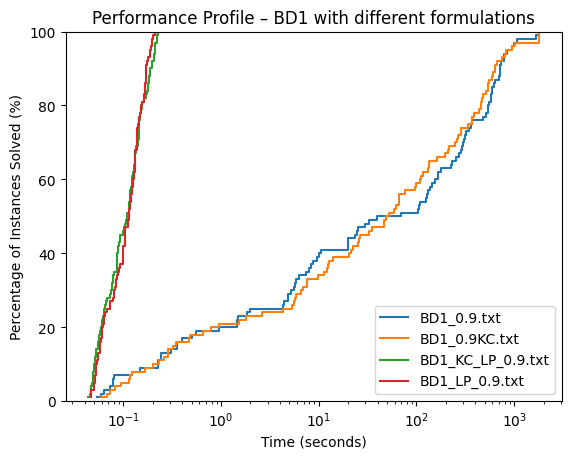

In [170]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

for file in selected_files:
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)

    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    plt.step(times, percentages, where="post", label=file)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD1 with different formulations")
plt.show()


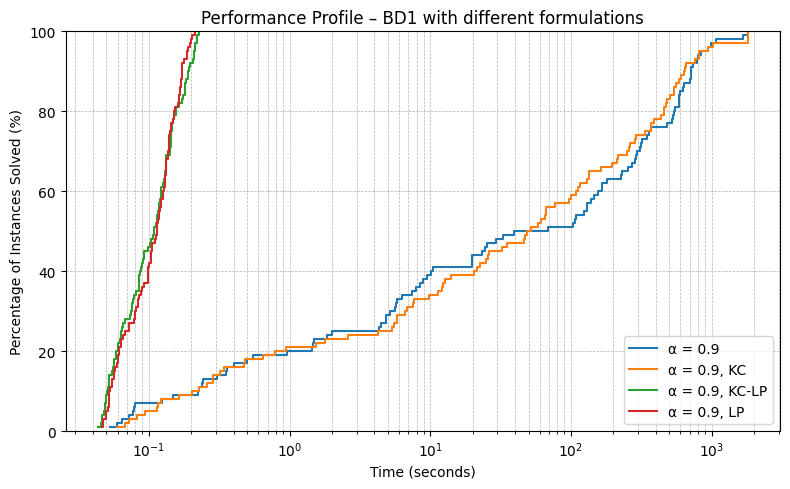

In [171]:
import numpy as np
import matplotlib.pyplot as plt

custom_labels = [
    "α = 0.9",
    "α = 0.9, KC",
    "α = 0.9, KC-LP",
    "α = 0.9, LP"
]

plt.figure(figsize=(8,5))

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt", "")
    plt.step(times, percentages, where="post", label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard for performance profiles
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD1 with different formulations")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


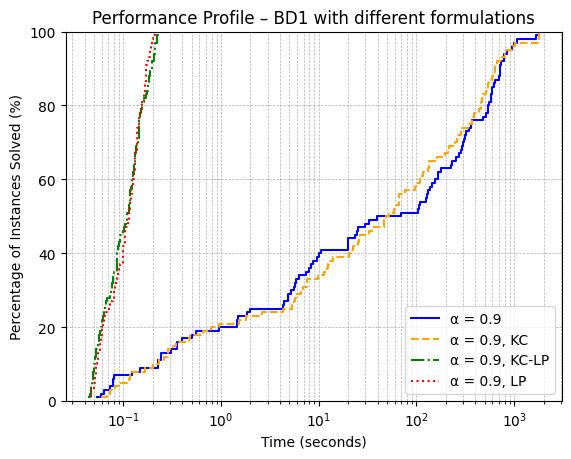

In [172]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

custom_labels = [
    "α = 0.9",
    "α = 0.9, KC",
    "α = 0.9, KC-LP",
    "α = 0.9, LP"
]

# Use default figure size (same as original)
plt.figure()

# Cycle colors and line styles for clarity
colors = cycle(['blue', 'orange', 'green', 'red', 'purple', 'brown'])
linestyles = cycle(['-', '--', '-.', ':', '-', '--'])

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # Optional: filter by folder
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label if available
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt","")

    plt.step(times, percentages, where='post', label=label,
             color=next(colors), linestyle=next(linestyles))

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")
plt.ylim(0, 100)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.title("Performance Profile – BD1 with different formulations")
plt.show()


Data visualization BD3

In [173]:
selected_files = final_df["file"].unique()[15:21]
print(selected_files)

['BD3_0.5.txt' 'BD3_0.6.txt' 'BD3_0.7.txt' 'BD3_0.8.txt' 'BD3_0.9.txt'
 'BD3_1.txt']


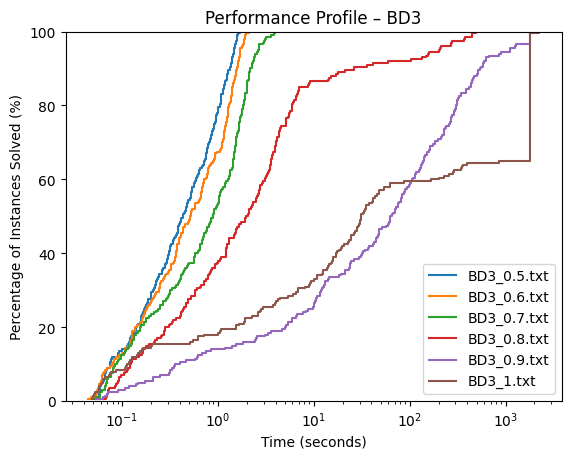

In [174]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

for file in selected_files:
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)

    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    plt.step(times, percentages, where="post", label=file)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD3")
plt.show()


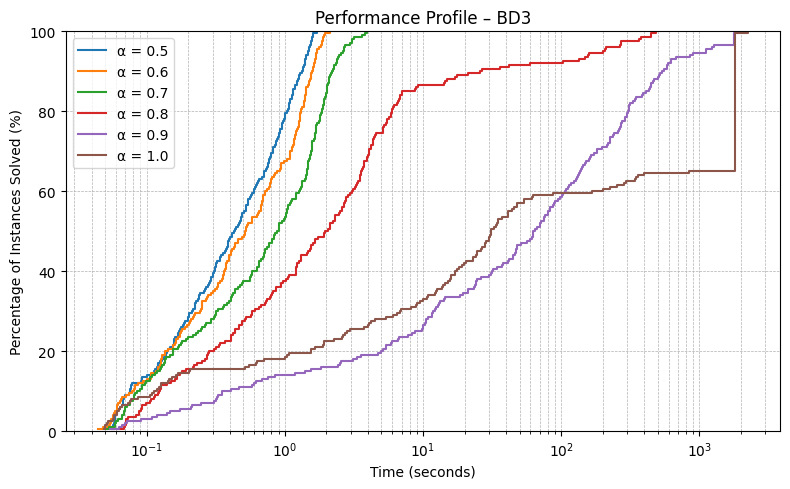

In [175]:
import numpy as np
import matplotlib.pyplot as plt

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

plt.figure(figsize=(8,5))

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt", "")
    plt.step(times, percentages, where="post", label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard for performance profiles
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD3")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


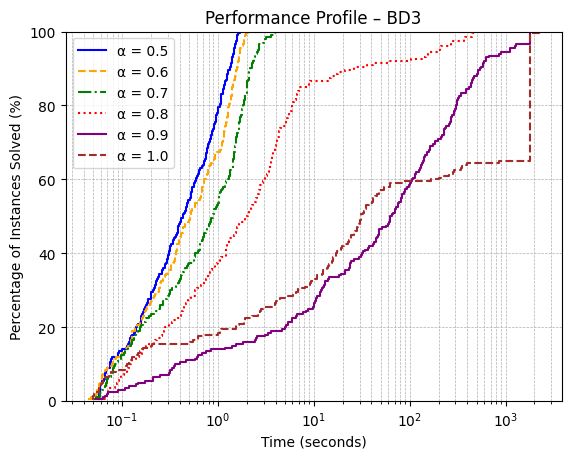

In [176]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

# Use default figure size (same as original)
plt.figure()

# Cycle colors and line styles for clarity
colors = cycle(['blue', 'orange', 'green', 'red', 'purple', 'brown'])
linestyles = cycle(['-', '--', '-.', ':', '-', '--'])

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # Optional: filter by folder
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label if available
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt","")

    plt.step(times, percentages, where='post', label=label,
             color=next(colors), linestyle=next(linestyles))

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")
plt.ylim(0, 100)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.title("Performance Profile – BD3")
plt.show()


Data visualization BD5

In [177]:
selected_files = final_df["file"].unique()[21:27]
print(selected_files)


['BD5_0.5.txt' 'BD5_0.6.txt' 'BD5_0.7.txt' 'BD5_0.8.txt' 'BD5_0.9.txt'
 'BD5_1.txt']


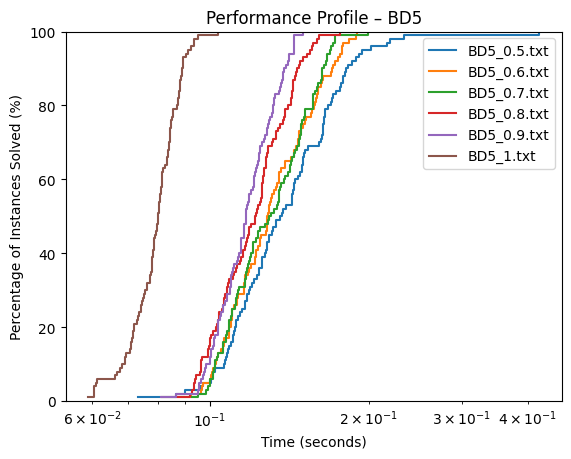

In [178]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

for file in selected_files:
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)

    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    plt.step(times, percentages, where="post", label=file)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD5")
plt.show()


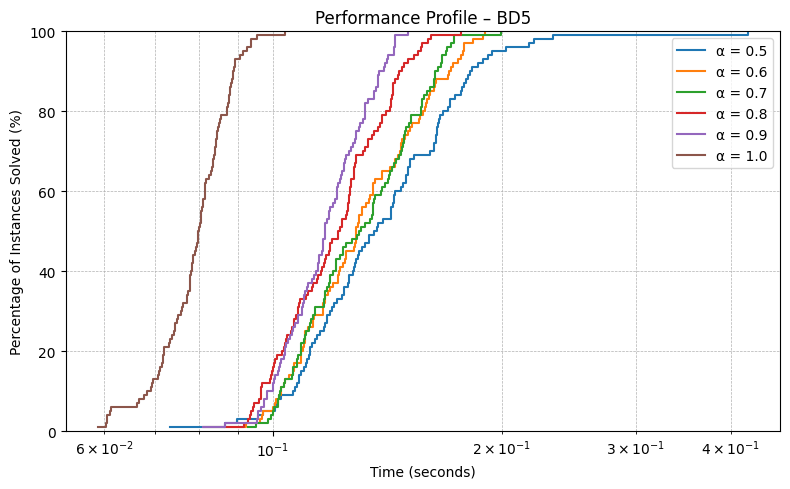

In [179]:
import numpy as np
import matplotlib.pyplot as plt

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

plt.figure(figsize=(8,5))

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt", "")
    plt.step(times, percentages, where="post", label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard for performance profiles
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD5")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()


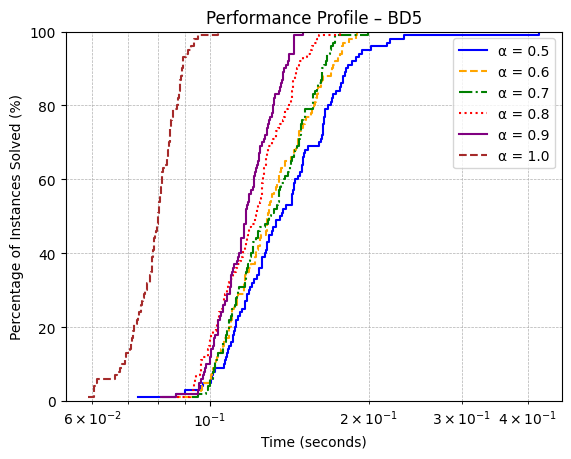

In [180]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

# Use default figure size (same as original)
plt.figure()

# Cycle colors and line styles for clarity
colors = cycle(['blue', 'orange', 'green', 'red', 'purple', 'brown'])
linestyles = cycle(['-', '--', '-.', ':', '-', '--'])

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # Optional: filter by folder
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label if available
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt","")

    plt.step(times, percentages, where='post', label=label,
             color=next(colors), linestyle=next(linestyles))

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")
plt.ylim(0, 100)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.title("Performance Profile – BD5")
plt.show()


Data visualization BD6

In [181]:
selected_files = final_df["file"].unique()[27:33]
print(selected_files)


['BD6_0.5.txt' 'BD6_0.6.txt' 'BD6_0.7.txt' 'BD6_0.8.txt' 'BD6_0.9.txt'
 'BD6_1.txt']


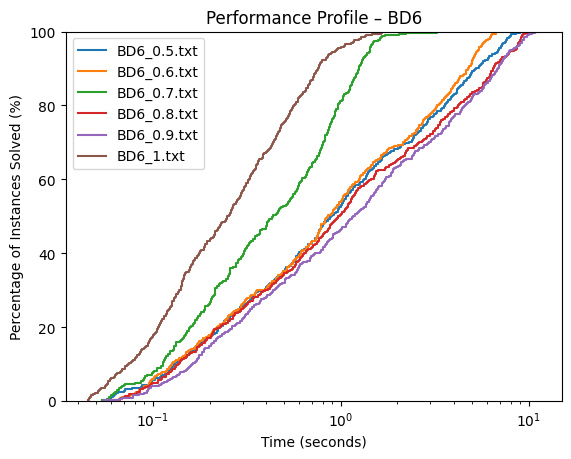

In [182]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

for file in selected_files:
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)

    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    plt.step(times, percentages, where="post", label=file)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD6")
plt.show()

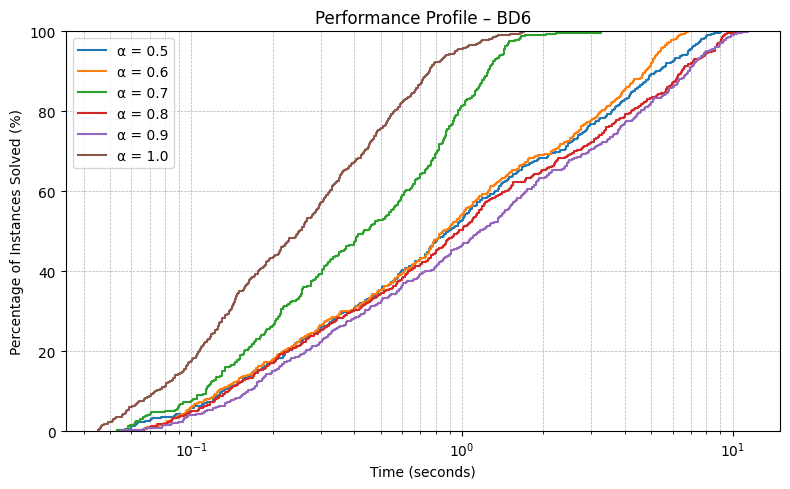

In [183]:
import numpy as np
import matplotlib.pyplot as plt

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

plt.figure(figsize=(8,5))

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # OPTIONAL: keep only one testbed
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt", "")
    plt.step(times, percentages, where="post", label=label)

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")  # log scale is standard for performance profiles
plt.ylim(0, 100)
plt.legend()
plt.title("Performance Profile – BD6")
plt.grid(True, which="both", ls="--", lw=0.5)
plt.tight_layout()
plt.show()

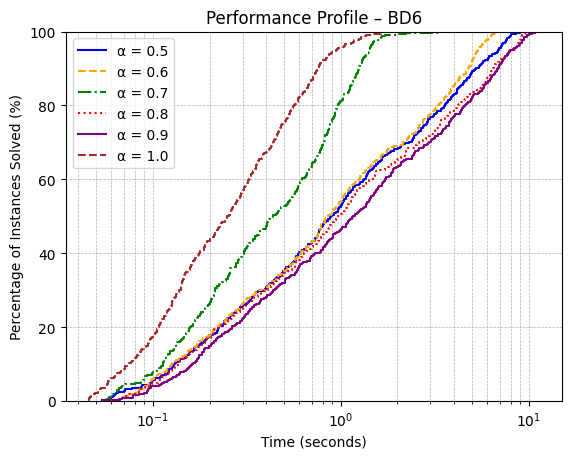

In [184]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

custom_labels = [
    "α = 0.5",
    "α = 0.6",
    "α = 0.7",
    "α = 0.8",
    "α = 0.9",
    "α = 1.0"
]

# Use default figure size (same as original)
plt.figure()

# Cycle colors and line styles for clarity
colors = cycle(['blue', 'orange', 'green', 'red', 'purple', 'brown'])
linestyles = cycle(['-', '--', '-.', ':', '-', '--'])

for i, file in enumerate(selected_files):
    df_file = final_df[final_df["file"] == file]

    # Optional: filter by folder
    # df_file = df_file[df_file["folder"] == "BD0"]

    times = np.sort(df_file["solve_time"].values)
    N = len(times)
    percentages = np.arange(1, N + 1) / N * 100

    # Use custom label if available
    label = custom_labels[i] if i < len(custom_labels) else file.replace(".txt","")

    plt.step(times, percentages, where='post', label=label,
             color=next(colors), linestyle=next(linestyles))

plt.xlabel("Time (seconds)")
plt.ylabel("Percentage of Instances Solved (%)")
plt.xscale("log")
plt.ylim(0, 100)
plt.grid(True, which="both", ls="--", lw=0.5)
plt.legend()
plt.title("Performance Profile – BD6")
plt.show()


New results

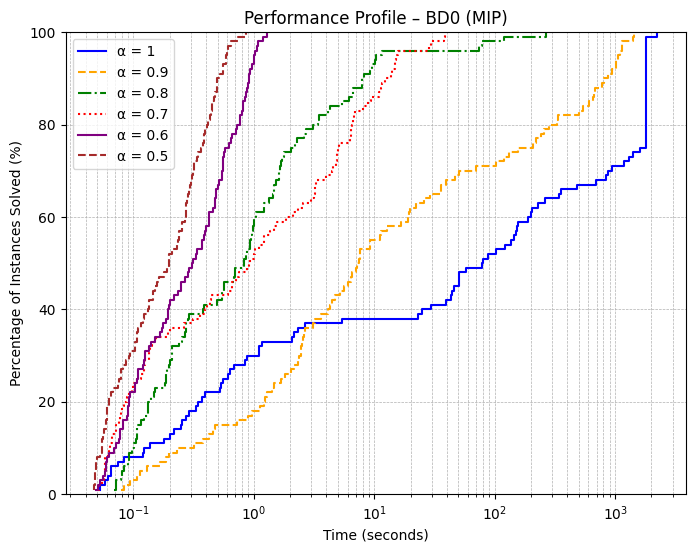

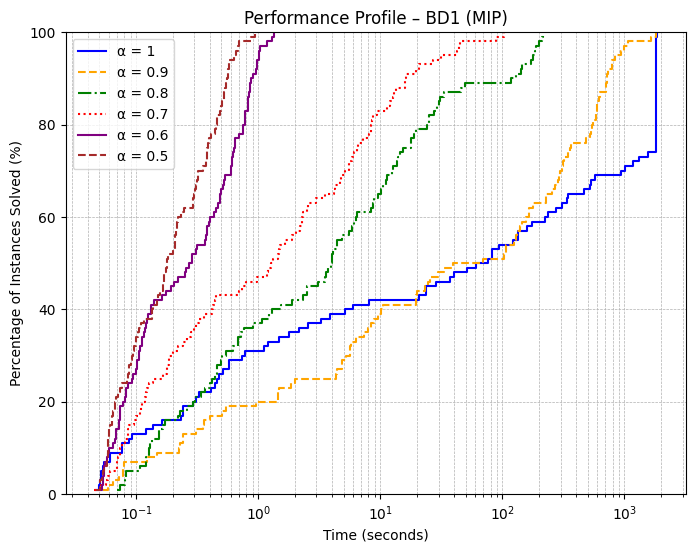

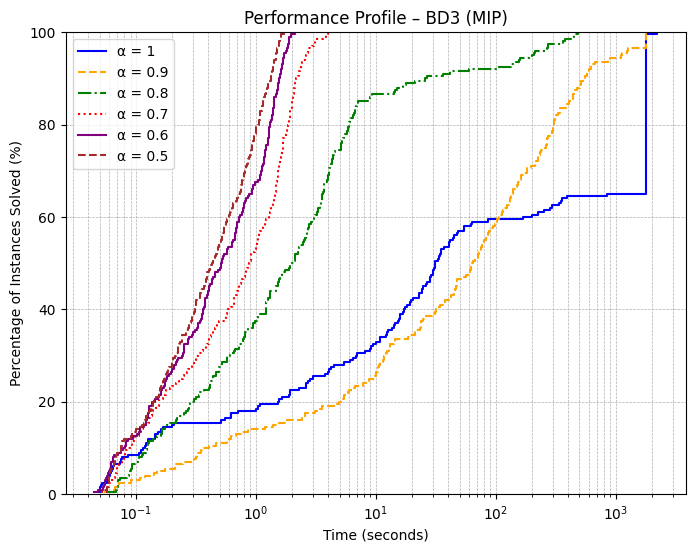

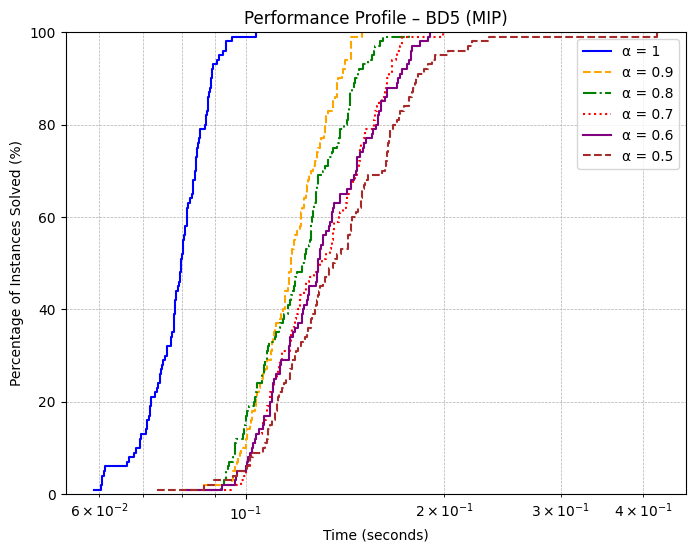

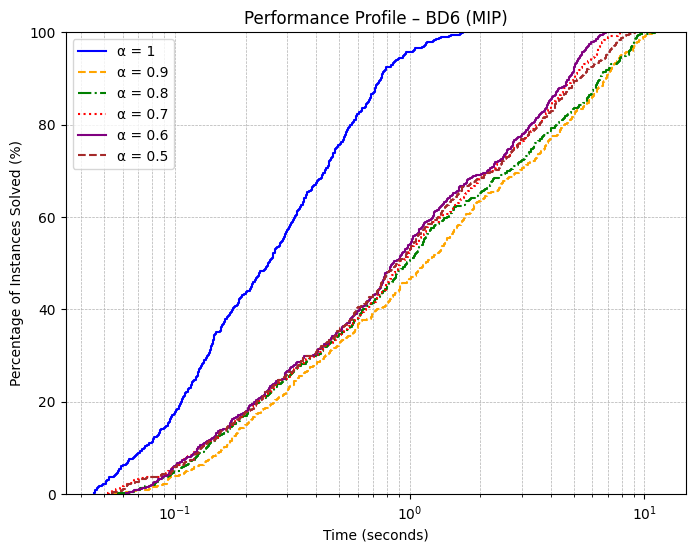

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Path to your Excel file
file_path = r"C:\Users\betsie_0410\Downloads\all_results.xlsx"

# Sheet names for each BD dataset
bd_names = ["BD0", "BD1", "BD3", "BD5", "BD6"]

# Alpha values
alphas = ["1", "0.9", "0.8", "0.7", "0.6", "0.5"]
labels = [f"α = {a}" for a in alphas]

for bd_name in bd_names:
    # Read each sheet
    try:
        df = pd.read_excel(file_path, sheet_name=bd_name)
    except ValueError:
        print(f"Sheet {bd_name} not found in Excel file.")
        continue

    plt.figure(figsize=(8,6))
    colors = cycle(['blue','orange','green','red','purple','brown'])
    linestyles = cycle(['-','--','-.',':','-','--'])

    for i, alpha in enumerate(alphas):
        col = f"t{alpha}_MIP"  # or use _IE if needed
        if col not in df.columns:
            print(f"Column {col} not found in sheet {bd_name}")
            continue

        times = np.sort(df[col].dropna().values)
        N = len(times)
        percentages = np.arange(1, N+1) / N * 100

        plt.step(times, percentages, where='post',
                 label=labels[i], color=next(colors), linestyle=next(linestyles))

    plt.xlabel("Time (seconds)")
    plt.ylabel("Percentage of Instances Solved (%)")
    plt.xscale("log")
    plt.ylim(0,100)
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.legend()
    plt.title(f"Performance Profile – {bd_name} (MIP)")
    plt.show()

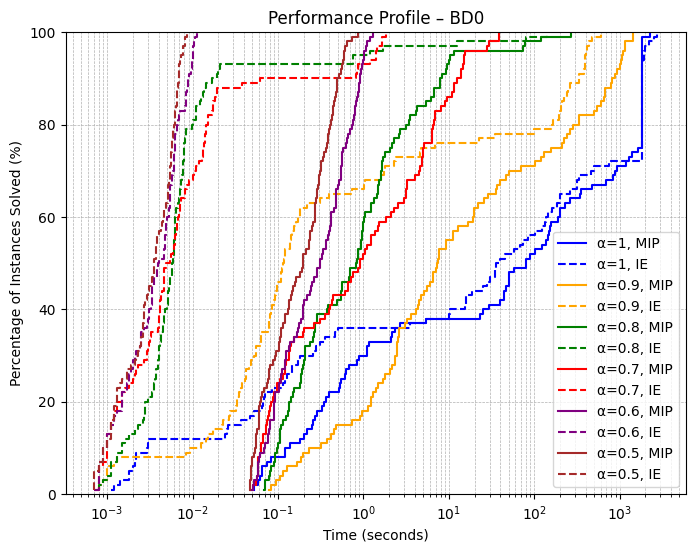

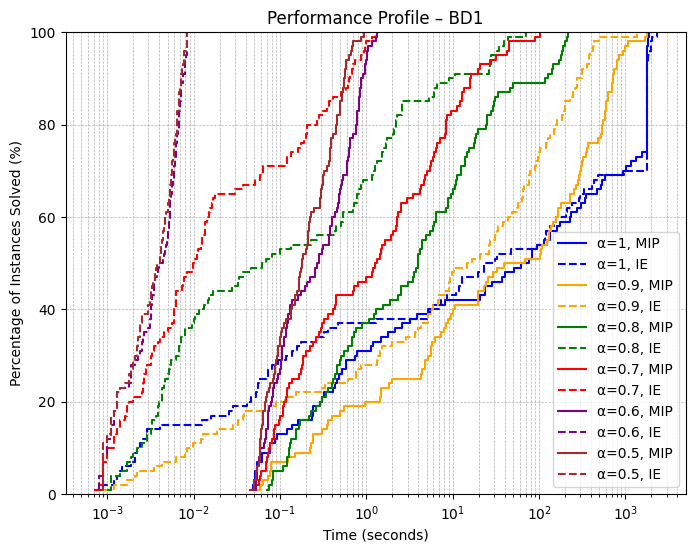

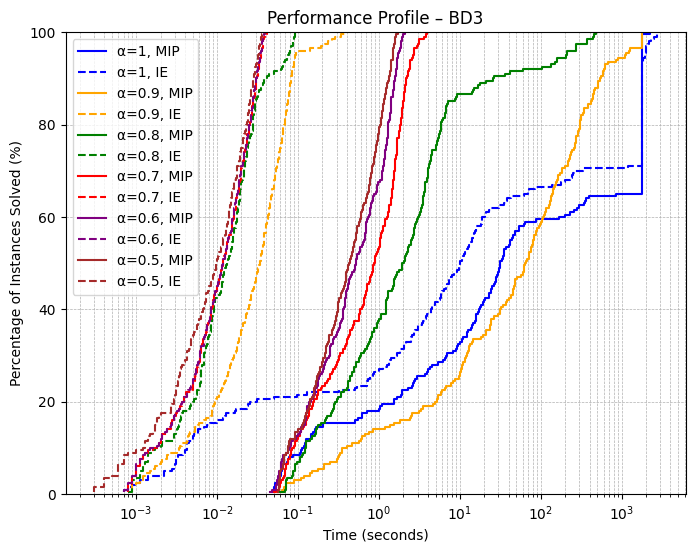

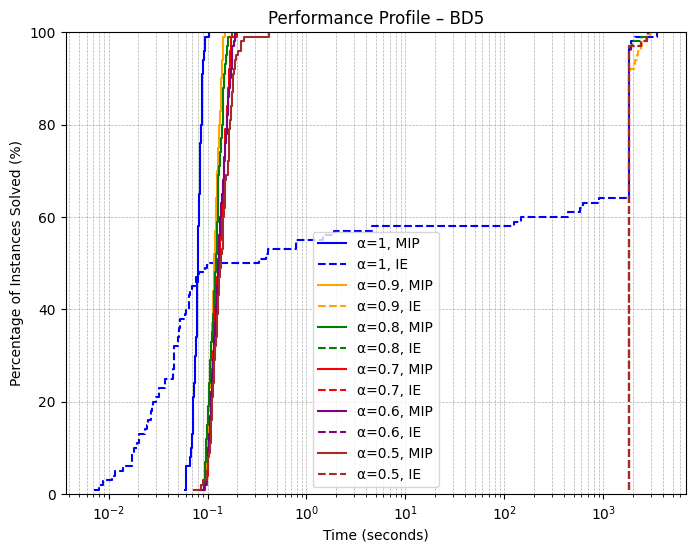

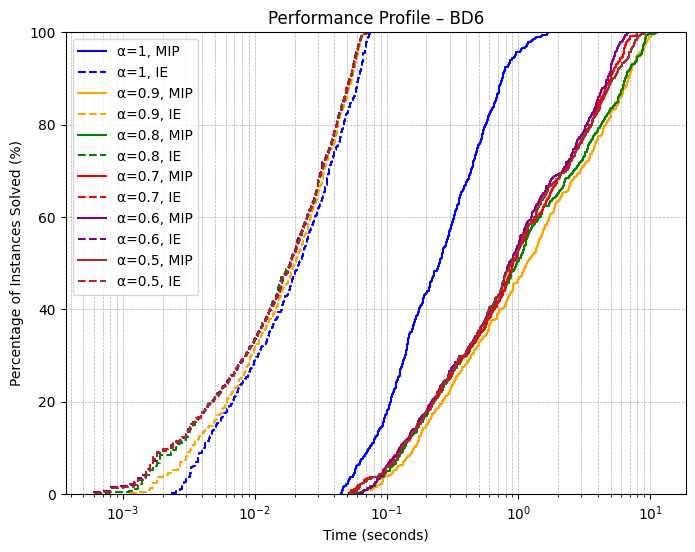

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Path to your Excel file
file_path = r"C:\Users\betsie_0410\Downloads\all_results.xlsx"

# Sheet names for each BD dataset
bd_names = ["BD0", "BD1", "BD3", "BD5", "BD6"]

# Alpha values
alphas = ["1", "0.9", "0.8", "0.7", "0.6", "0.5"]

# Solver types
solvers = ["MIP", "IE"]

# Colors for alpha values
colors = ['blue','orange','green','red','purple','brown']

for bd_name in bd_names:
    # Read each sheet
    try:
        df = pd.read_excel(file_path, sheet_name=bd_name)
    except ValueError:
        print(f"Sheet {bd_name} not found in Excel file.")
        continue

    plt.figure(figsize=(8,6))
    color_cycle = cycle(colors)
    linestyles = cycle(['-','--'])  # solid for MIP, dashed for IE

    for i, alpha in enumerate(alphas):
        color = next(color_cycle)

        for solver in solvers:
            col = f"t{alpha}_{solver}"
            if col not in df.columns:
                print(f"Column {col} not found in sheet {bd_name}")
                continue

            times = np.sort(df[col].dropna().values)
            N = len(times)
            percentages = np.arange(1, N+1) / N * 100

            plt.step(times, percentages, where='post',
                     label=f"α={alpha}, {solver}",
                     color=color,
                     linestyle=next(linestyles))

    plt.xlabel("Time (seconds)")
    plt.ylabel("Percentage of Instances Solved (%)")
    plt.xscale("log")
    plt.ylim(0,100)
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.legend()
    plt.title(f"Performance Profile – {bd_name}")
    plt.show()

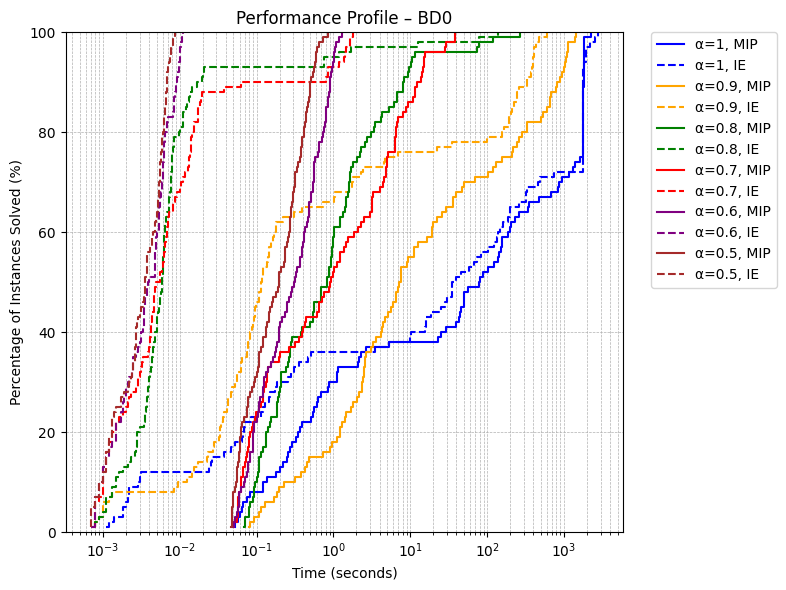

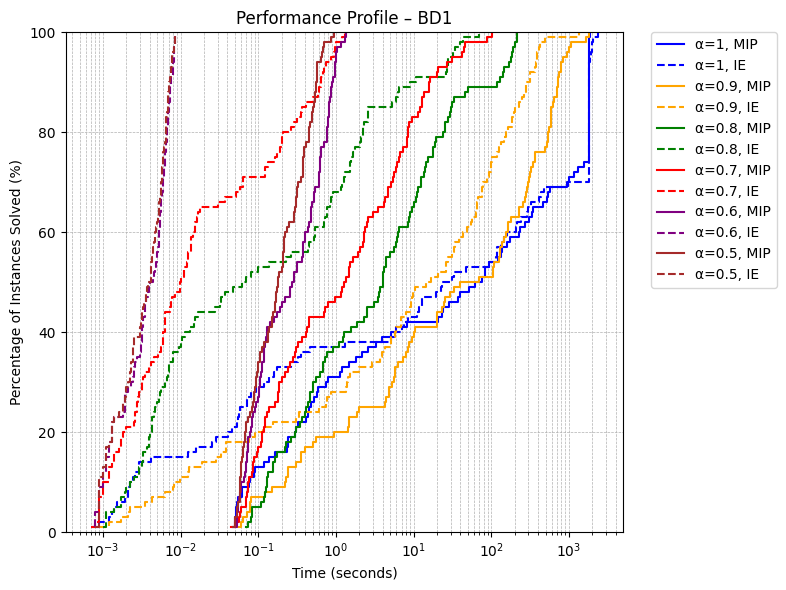

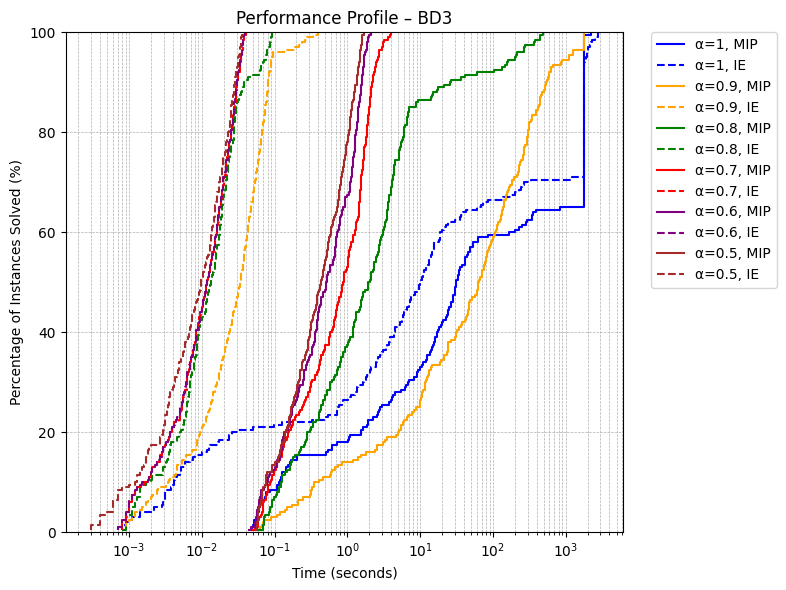

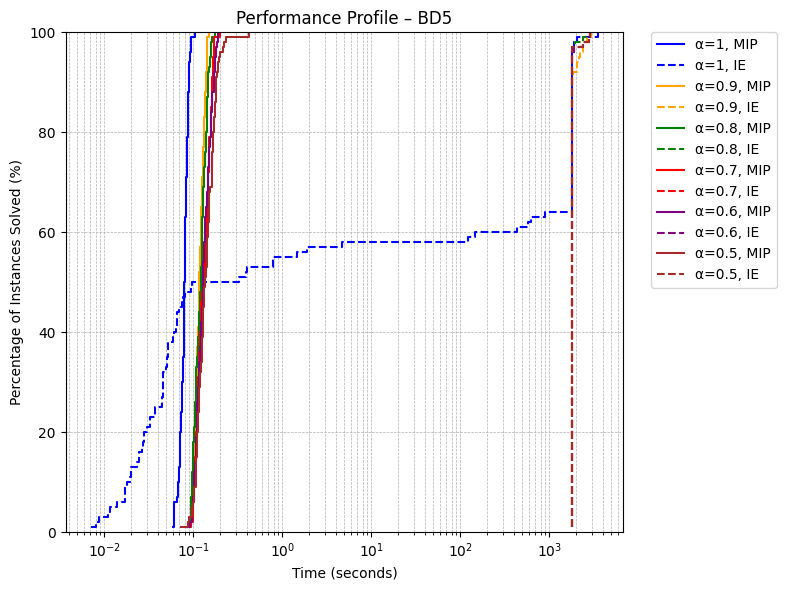

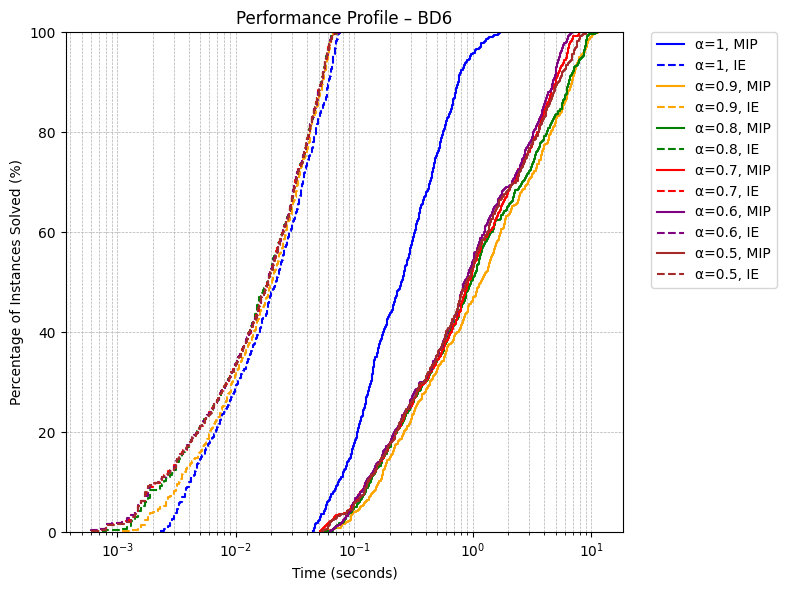

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Path to your Excel file
file_path = r"C:\Users\betsie_0410\Downloads\all_results.xlsx"

# Sheet names for each BD dataset
bd_names = ["BD0", "BD1", "BD3", "BD5", "BD6"]

# Alpha values
alphas = ["1", "0.9", "0.8", "0.7", "0.6", "0.5"]

# Solver types
solvers = ["MIP", "IE"]

# Colors for alpha values
colors = ['blue','orange','green','red','purple','brown']

for bd_name in bd_names:
    # Read each sheet
    try:
        df = pd.read_excel(file_path, sheet_name=bd_name)
    except ValueError:
        print(f"Sheet {bd_name} not found in Excel file.")
        continue

    plt.figure(figsize=(8,6))
    color_cycle = cycle(colors)
    linestyles = cycle(['-','--'])  # solid for MIP, dashed for IE

    for i, alpha in enumerate(alphas):
        color = next(color_cycle)

        for solver in solvers:
            col = f"t{alpha}_{solver}"
            if col not in df.columns:
                print(f"Column {col} not found in sheet {bd_name}")
                continue

            times = np.sort(df[col].dropna().values)
            N = len(times)
            percentages = np.arange(1, N+1) / N * 100

            plt.step(times, percentages, where='post',
                     label=f"α={alpha}, {solver}",
                     color=color,
                     linestyle=next(linestyles))

    plt.xlabel("Time (seconds)")
    plt.ylabel("Percentage of Instances Solved (%)")
    plt.xscale("log")
    plt.ylim(0,100)
    plt.grid(True, which="both", ls="--", lw=0.5)

    # Move legend outside the plot
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title(f"Performance Profile – {bd_name}")
    plt.tight_layout()  # adjust plot to make space for the legend
    plt.show()

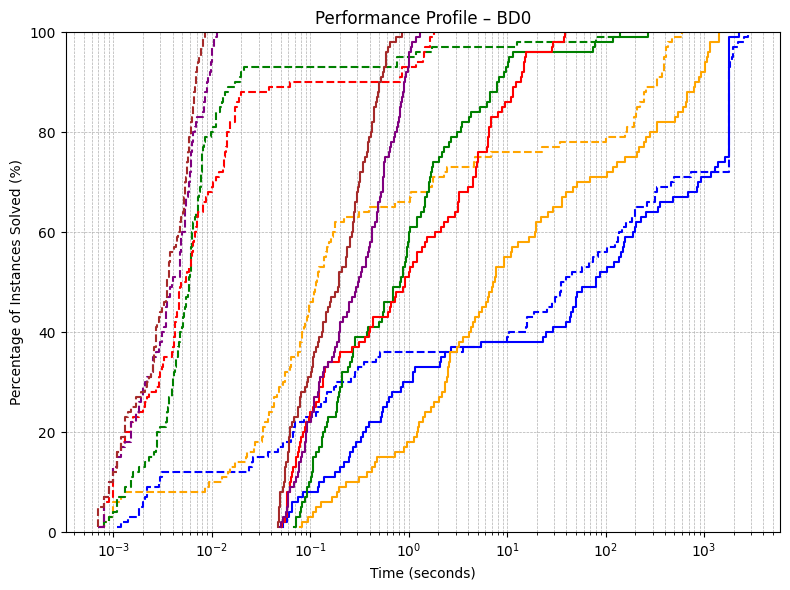

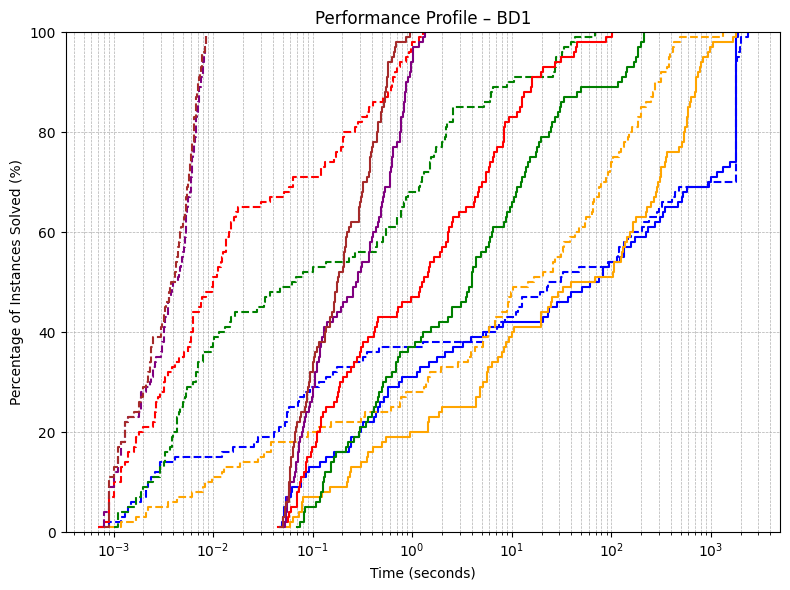

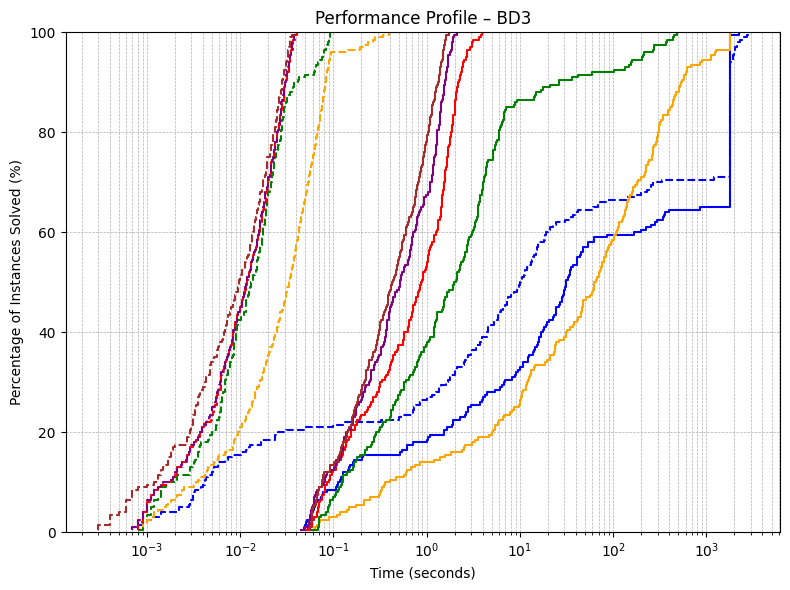

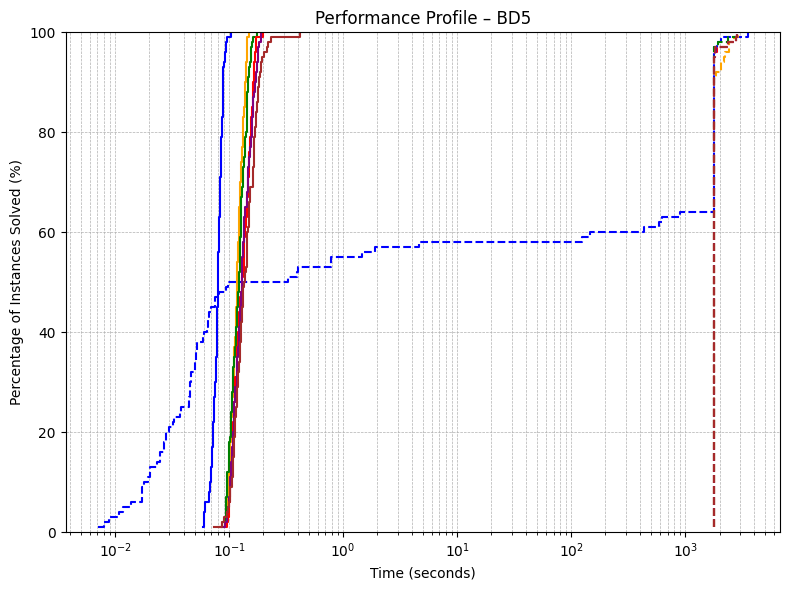

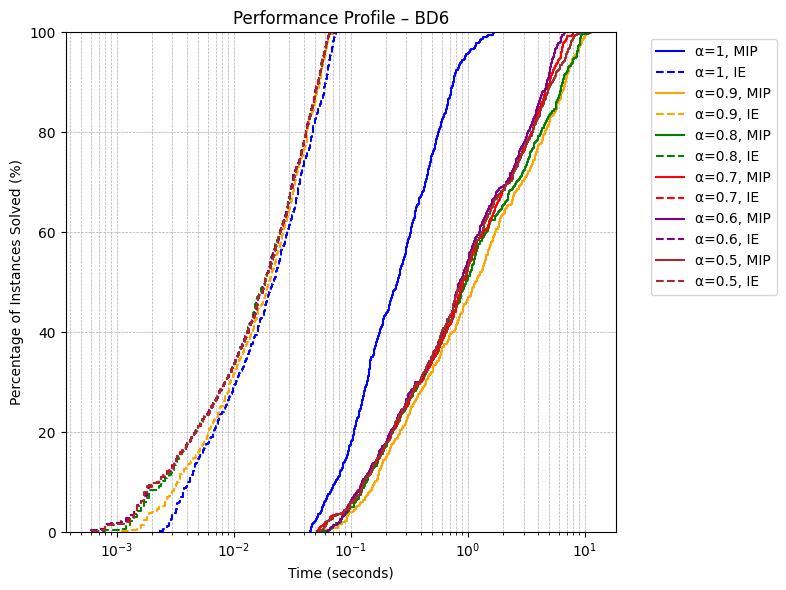

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Path to your Excel file
file_path = r"C:\Users\betsie_0410\Downloads\all_results.xlsx"

# Sheet names
bd_names = ["BD0", "BD1", "BD3", "BD5", "BD6"]

# Alpha values
alphas = ["1", "0.9", "0.8", "0.7", "0.6", "0.5"]

# Solver types
solvers = ["MIP", "IE"]

# Colors
colors = ['blue','orange','green','red','purple','brown']

legend_handles = None
legend_labels = None

for bd_name in bd_names:

    try:
        df = pd.read_excel(file_path, sheet_name=bd_name)
    except ValueError:
        print(f"Sheet {bd_name} not found.")
        continue

    plt.figure(figsize=(8,6))

    color_cycle = cycle(colors)

    for i, alpha in enumerate(alphas):

        color = next(color_cycle)

        for solver in solvers:

            linestyle = '-' if solver == "MIP" else '--'

            col = f"t{alpha}_{solver}"

            if col not in df.columns:
                continue

            times = np.sort(df[col].dropna().values)
            N = len(times)
            percentages = np.arange(1, N+1) / N * 100

            line, = plt.step(
                times,
                percentages,
                where='post',
                label=f"α={alpha}, {solver}",
                color=color,
                linestyle=linestyle
            )

    plt.xlabel("Time (seconds)")
    plt.ylabel("Percentage of Instances Solved (%)")
    plt.xscale("log")
    plt.ylim(0,100)
    plt.grid(True, which="both", ls="--", lw=0.5)
    plt.title(f"Performance Profile – {bd_name}")

    # Capture legend only once
    if legend_handles is None:
        legend_handles, legend_labels = plt.gca().get_legend_handles_labels()

    # Show legend only on last plot
    if bd_name == bd_names[-1]:
        plt.legend(
            legend_handles,
            legend_labels,
            bbox_to_anchor=(1.05, 1),
            loc='upper left'
        )

    plt.tight_layout()
    plt.show()

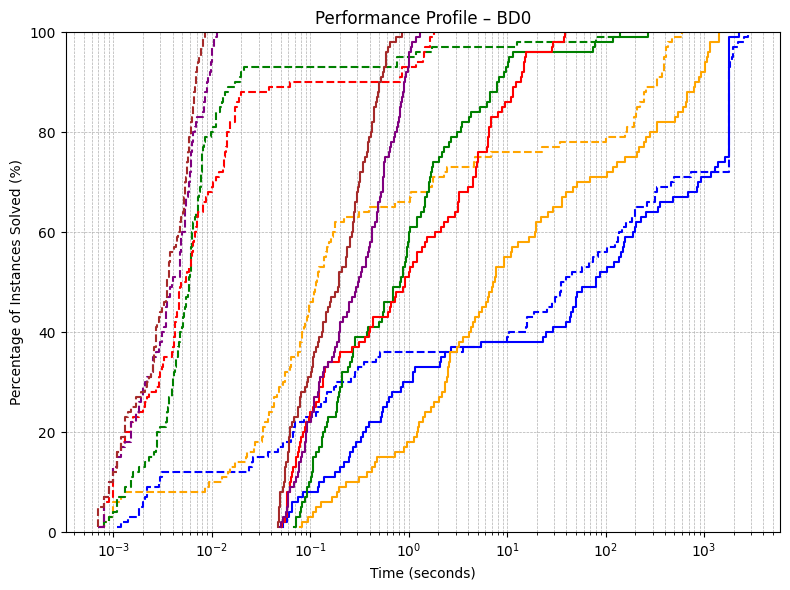

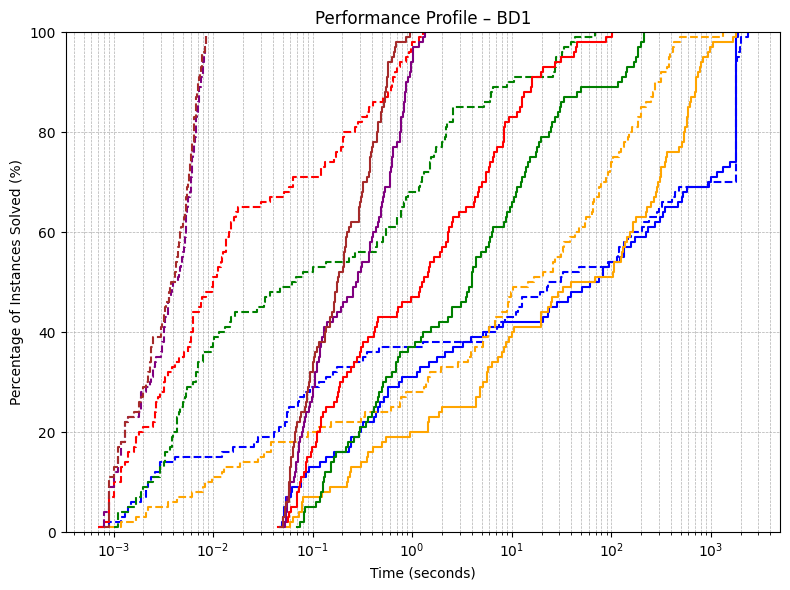

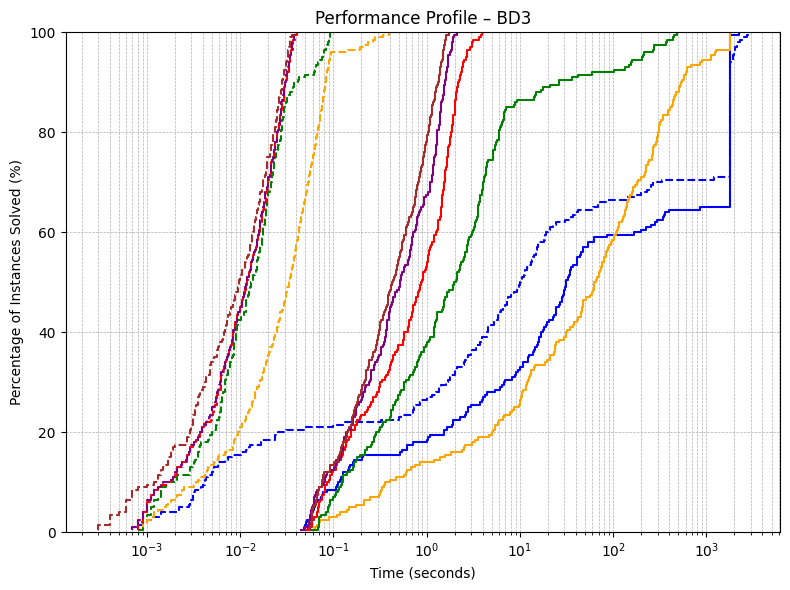

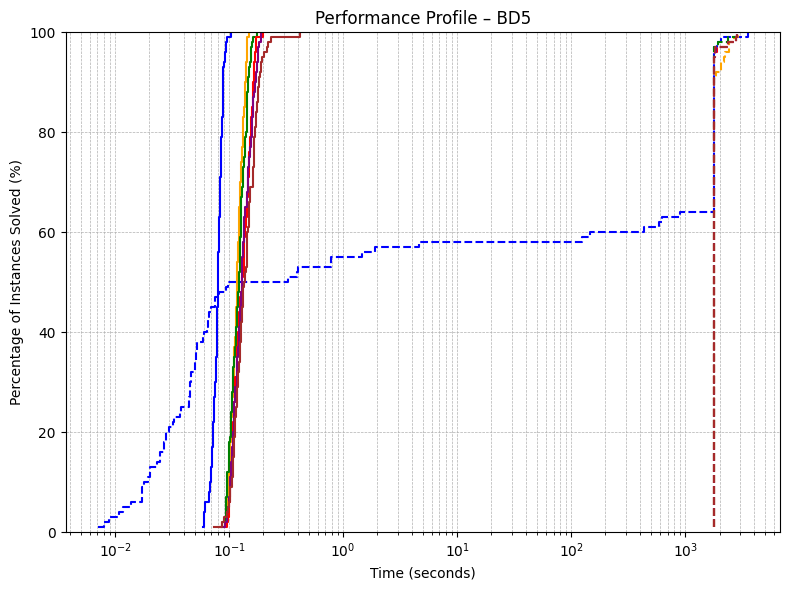

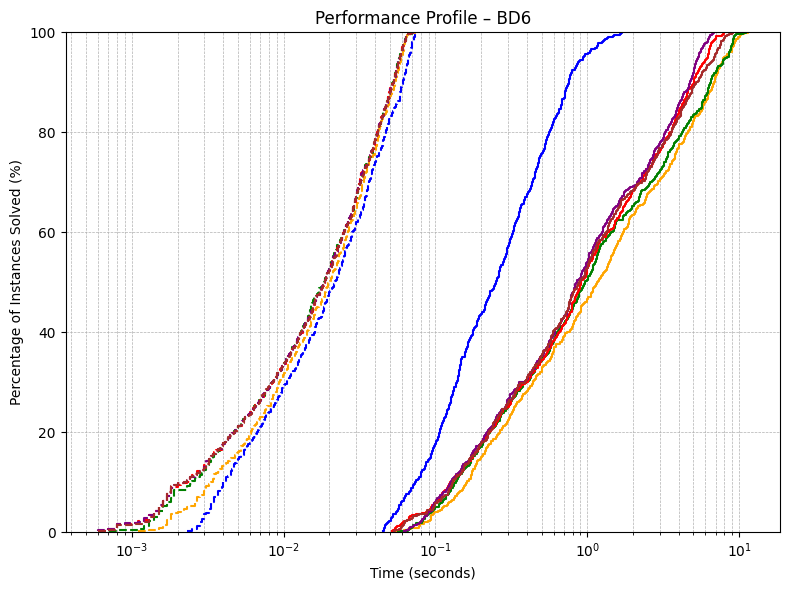

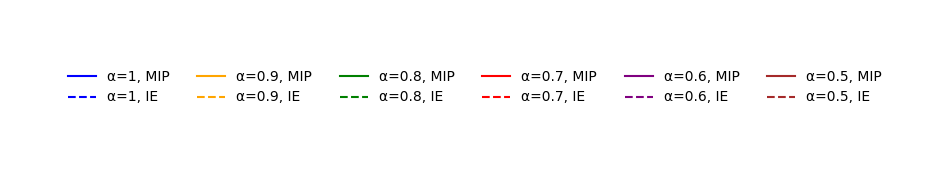

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Path to Excel
file_path = r"C:\Users\betsie_0410\Downloads\all_results.xlsx"

# Sheets
bd_names = ["BD0", "BD1", "BD3", "BD5", "BD6"]

alphas = ["1", "0.9", "0.8", "0.7", "0.6", "0.5"]
solvers = ["MIP", "IE"]

colors = ['blue','orange','green','red','purple','brown']

legend_handles = []
legend_labels = []

for bd_name in bd_names:

    df = pd.read_excel(file_path, sheet_name=bd_name)

    plt.figure(figsize=(8,6))
    color_cycle = cycle(colors)

    for alpha in alphas:

        color = next(color_cycle)

        for solver in solvers:

            linestyle = '-' if solver == "MIP" else '--'
            col = f"t{alpha}_{solver}"

            if col not in df.columns:
                continue

            times = np.sort(df[col].dropna().values)
            N = len(times)
            percentages = np.arange(1, N+1) / N * 100

            line, = plt.step(
                times,
                percentages,
                where='post',
                color=color,
                linestyle=linestyle,
                label=f"α={alpha}, {solver}"
            )

            # store legend entries only once
            if len(legend_handles) < len(alphas)*len(solvers):
                legend_handles.append(line)
                legend_labels.append(f"α={alpha}, {solver}")

    plt.xlabel("Time (seconds)")
    plt.ylabel("Percentage of Instances Solved (%)")
    plt.xscale("log")
    plt.ylim(0,100)
    plt.grid(True, which="both", ls="--", lw=0.5)

    plt.title(f"Performance Profile – {bd_name}")

    # no legend in the plots
    plt.tight_layout()
    plt.show()


# -------- legend figure --------

plt.figure(figsize=(12,2))

plt.legend(
    legend_handles,
    legend_labels,
    loc="center",
    ncol=6,   # landscape layout
    frameon=False
)

plt.axis("off")
plt.show()

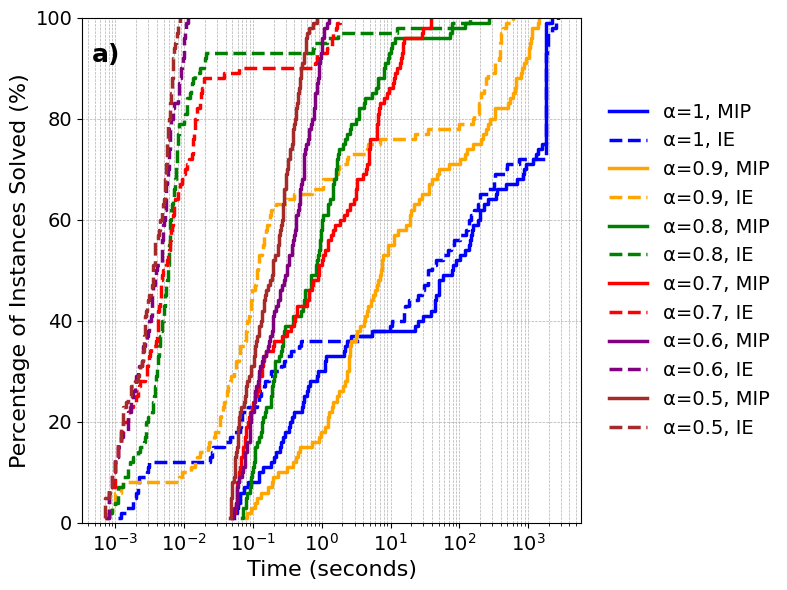

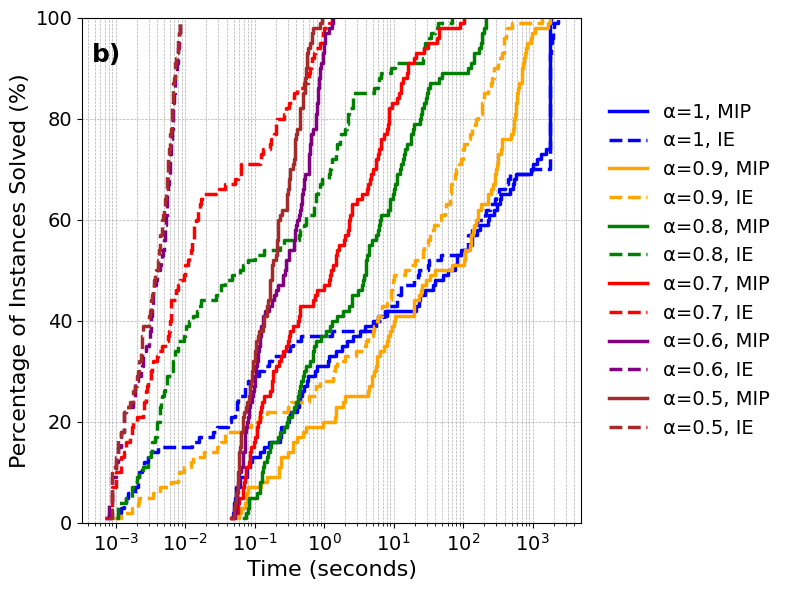

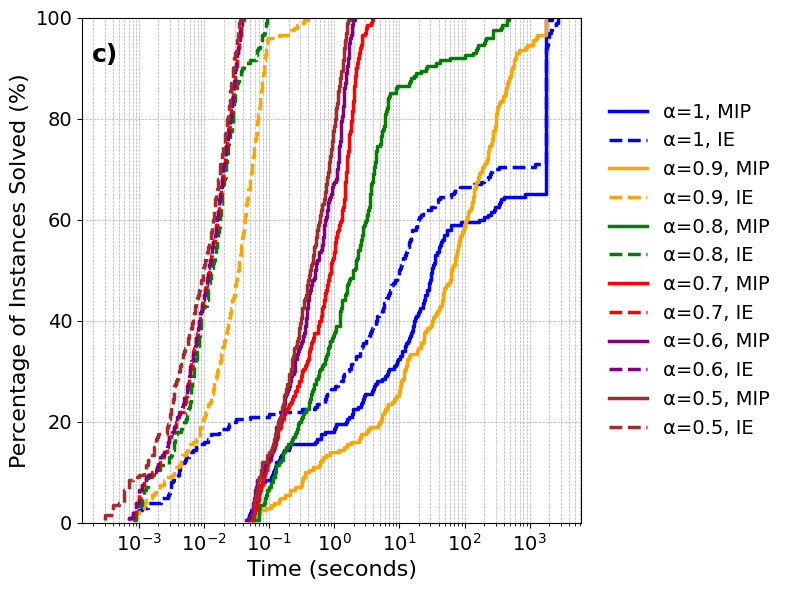

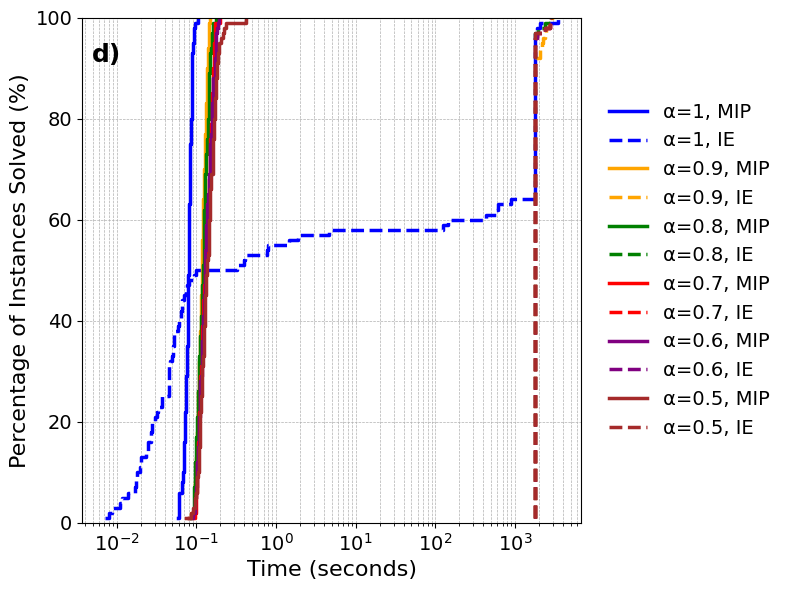

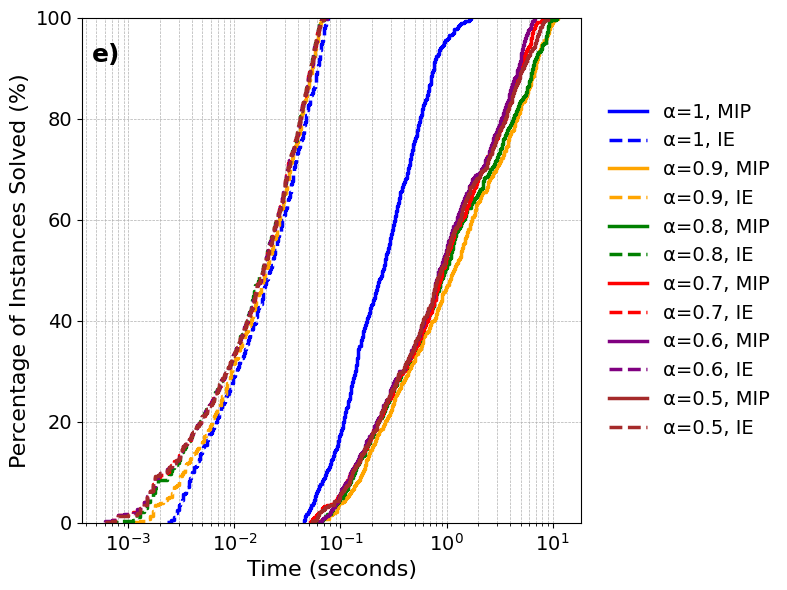

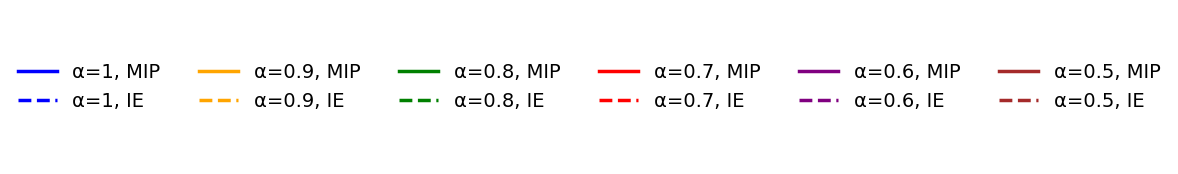

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle

# Path to Excel
file_path = r"C:\Users\betsie_0410\Downloads\all_results.xlsx"

# Sheets
bd_names = ["BD0", "BD1", "BD3", "BD5", "BD6"]

alphas = ["1", "0.9", "0.8", "0.7", "0.6", "0.5"]
solvers = ["MIP", "IE"]

colors = ['blue','orange','green','red','purple','brown']

legend_handles = []
legend_labels = []

letters = ['a)', 'b)', 'c)', 'd)', 'e)']

# Font sizes
axis_label_size = 16
tick_size = 14
title_size = 18
subplot_label_size = 18
legend_size = 14

for idx, bd_name in enumerate(bd_names):

    df = pd.read_excel(file_path, sheet_name=bd_name)

    plt.figure(figsize=(8,6))
    color_cycle = cycle(colors)

    for alpha in alphas:

        color = next(color_cycle)

        for solver in solvers:

            linestyle = '-' if solver == "MIP" else '--'
            col = f"t{alpha}_{solver}"

            if col not in df.columns:
                continue

            times = np.sort(df[col].dropna().values)
            N = len(times)
            percentages = np.arange(1, N+1) / N * 100

            line, = plt.step(
                times,
                percentages,
                where='post',
                color=color,
                linestyle=linestyle,
                linewidth =2.5,
                label=f"α={alpha}, {solver}"
            )

            if len(legend_handles) < len(alphas)*len(solvers):
                legend_handles.append(line)
                legend_labels.append(f"α={alpha}, {solver}")

    plt.xlabel("Time (seconds)", fontsize=axis_label_size)
    plt.ylabel("Percentage of Instances Solved (%)", fontsize=axis_label_size)

    plt.xscale("log")
    plt.ylim(0,100)

    plt.grid(True, which="both", ls="--", lw=0.5)

    # plt.title(f"Performance Profile – {bd_name}", fontsize=title_size)

    # Enlarge tick labels
    plt.tick_params(axis='both', which='major', labelsize=tick_size)

    # Add a), b), c) label
    plt.text(
        0.02, 0.95,
        letters[idx],
        transform=plt.gca().transAxes,
        fontsize=subplot_label_size,
        fontweight='bold',
        va='top'
    )

    plt.legend(
    fontsize=legend_size,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)
    plt.tight_layout()
    plt.show()


# Legend figure
plt.figure(figsize=(12,2))

plt.legend(
    legend_handles,
    legend_labels,
    loc="center",
    ncol=6,
    frameon=False,
    fontsize=legend_size
)

plt.axis("off")
plt.show()